In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score


In [29]:
df = pd.read_csv('oasis_longitudinal.csv')

# Selección de atributos: Sex, Age, EDUC, SES, MMSE, eTIV, nWBV, ASF
features = ['Sex', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features]
y = df['CDR'].astype(str) # 4 clases: 0.0, 0.5, 1.0, 2.0

# Imputación de nulos (necesaria para Árboles en scikit-learn)
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X)

modelos_iter = []
clases_cdr = ['0.0', '0.5', '1.0', '2.0']

In [30]:
# Definición de configuraciones
configuraciones = {
    "Sin Control (Complejo)": DecisionTreeClassifier(random_state=42),
    "Con Control (Podado)": DecisionTreeClassifier(
        max_depth=5, 
        min_samples_leaf=10, 
        min_samples_split=20,
        criterion='gini',
        random_state=42
    )
}

resultados = {conf: {'train_f1': [], 'test_f1': []} for conf in configuraciones}

# Diseño Experimental: 10 validaciones independientes 80/20
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    for nombre, model in configuraciones.items():
        model.fit(X_train, y_train)
        
        # Evaluamos F1-macro por el desbalance de clases (CDR 2 tiene solo 3 casos)
        resultados[nombre]['train_f1'].append(f1_score(y_train, model.predict(X_train), average='macro'))
        resultados[nombre]['test_f1'].append(f1_score(y_test, model.predict(X_test), average='macro'))

# Reporte de métricas promedio ± DE
print("--- COMPARATIVA DE COMPLEJIDAD (F1-SCORE MACRO) ---")
for nombre in configuraciones:
    mean_train = np.mean(resultados[nombre]['train_f1'])
    mean_test = np.mean(resultados[nombre]['test_f1'])
    std_test = np.std(resultados[nombre]['test_f1'])
    print(f"{nombre}:")
    print(f"  Entrenamiento: {mean_train:.4f}")
    print(f"  Prueba:        {mean_test:.4f} ± {std_test:.4f}")
    

--- COMPARATIVA DE COMPLEJIDAD (F1-SCORE MACRO) ---
Sin Control (Complejo):
  Entrenamiento: 1.0000
  Prueba:        0.5428 ± 0.0857
Con Control (Podado):
  Entrenamiento: 0.5288
  Prueba:        0.5196 ± 0.0936


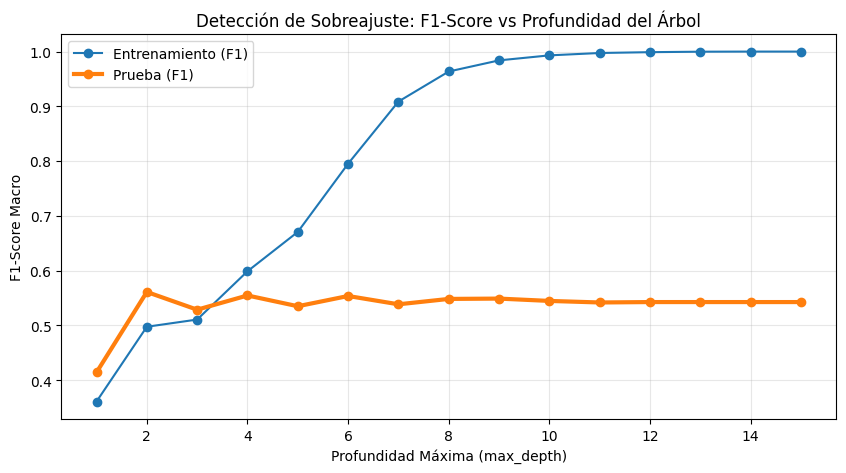

In [31]:
profundidades = range(1, 16)
train_scores = []
test_scores = []

for d in profundidades:
    # Promediamos 10 iteraciones por cada profundidad
    t_iter, v_iter = [], []
    for i in range(10):
        xt, xv, yt, yv = train_test_split(X_prep, y, test_size=0.2, random_state=i)
        dt = DecisionTreeClassifier(max_depth=d, random_state=42)
        dt.fit(xt, yt)
        t_iter.append(f1_score(yt, dt.predict(xt), average='macro'))
        v_iter.append(f1_score(yv, dt.predict(xv), average='macro'))
    train_scores.append(np.mean(t_iter))
    test_scores.append(np.mean(v_iter))

plt.figure(figsize=(10, 5))
plt.plot(profundidades, train_scores, label='Entrenamiento (F1)', marker='o')
plt.plot(profundidades, test_scores, label='Prueba (F1)', marker='o', linewidth=3)
plt.title("Detección de Sobreajuste: F1-Score vs Profundidad del Árbol")
plt.xlabel("Profundidad Máxima (max_depth)")
plt.ylabel("F1-Score Macro")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

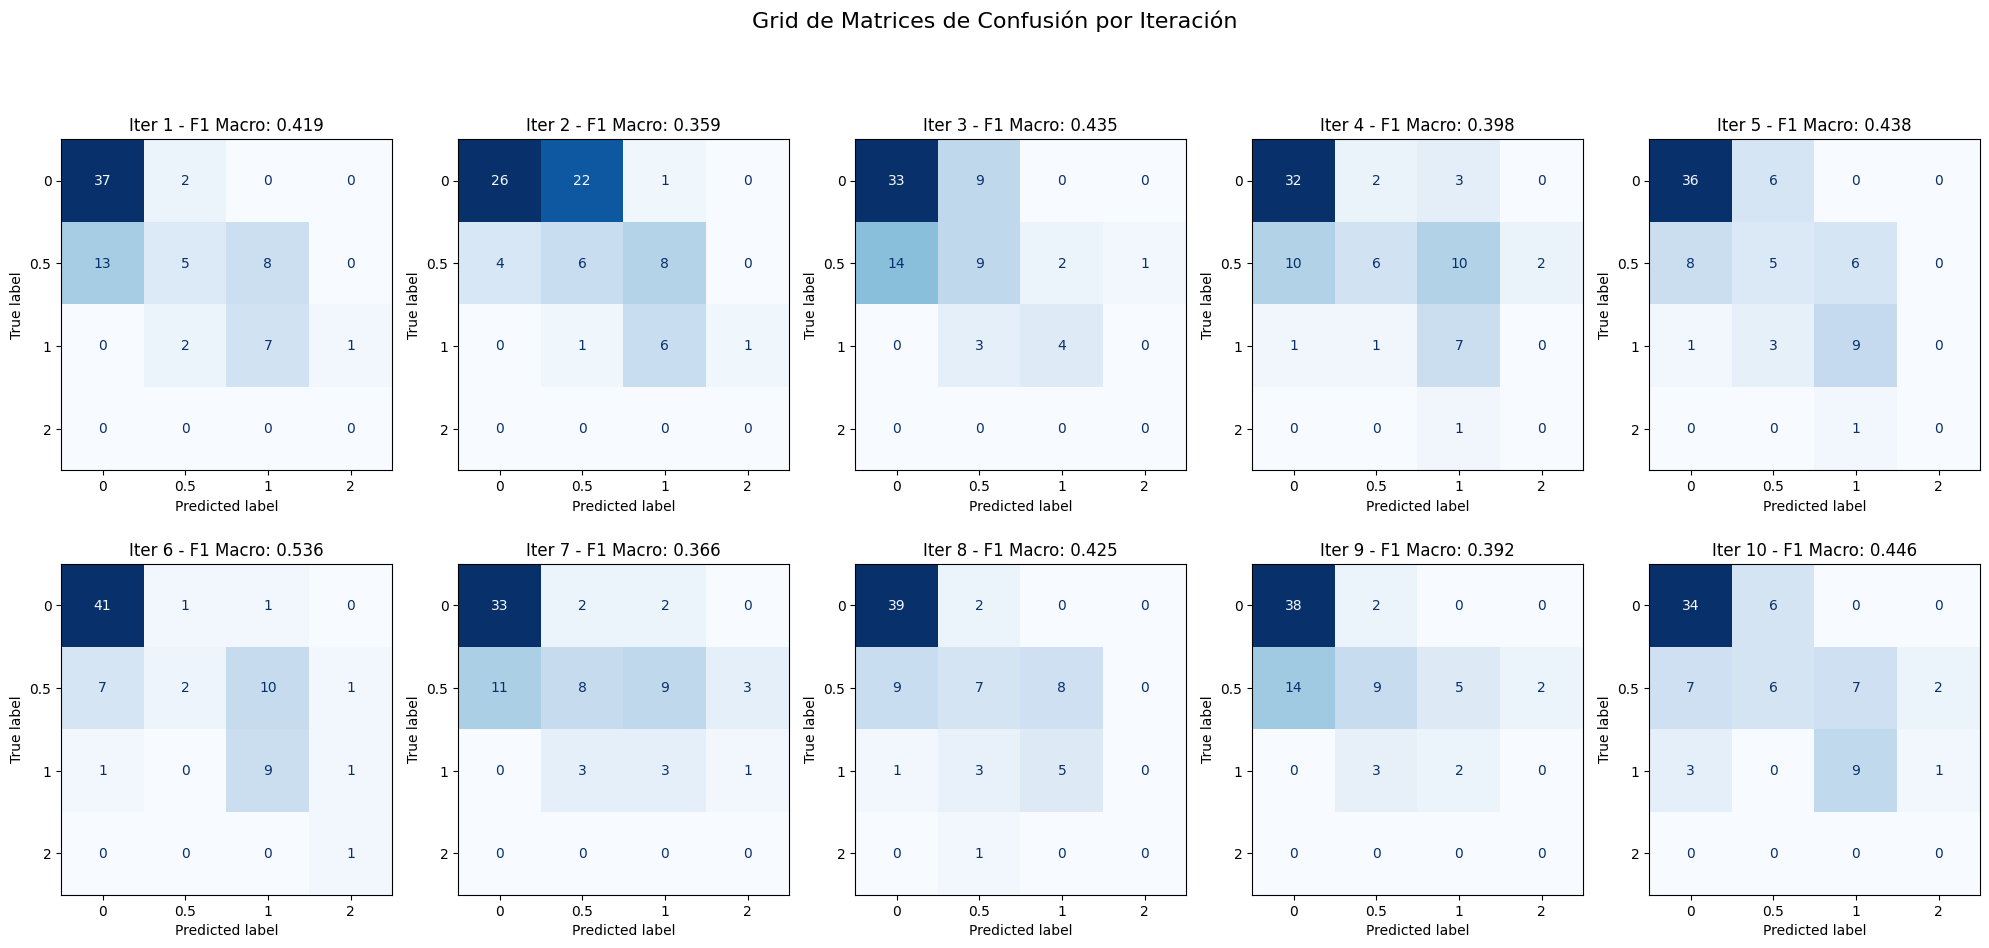

In [32]:
fig_cm, axes_cm = plt.subplots(2, 5, figsize=(20, 10))
axes_cm = axes_cm.flatten()

for i in range(10):
    # Partición aleatoria independiente
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # Entrenamiento con Control de Complejidad (max_depth=3 para visualización clara) [4]
    # Se usa class_weight='balanced' para compensar el desbalance de la clase CDR 2 [5]
    dt = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, 
                                class_weight='balanced', random_state=42)
    dt.fit(X_train, y_train)
    modelos_iter.append(dt)
    
    # Generación de Matriz de Confusión
    y_pred = dt.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=clases_cdr)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    disp.plot(ax=axes_cm[i], cmap='Blues', colorbar=False)
    
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    axes_cm[i].set_title(f"Iter {i+1} - F1 Macro: {f1_macro:.3f}")

fig_cm.suptitle("Grid de Matrices de Confusión por Iteración", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Generando visualización de la estructura de los 10 árboles...


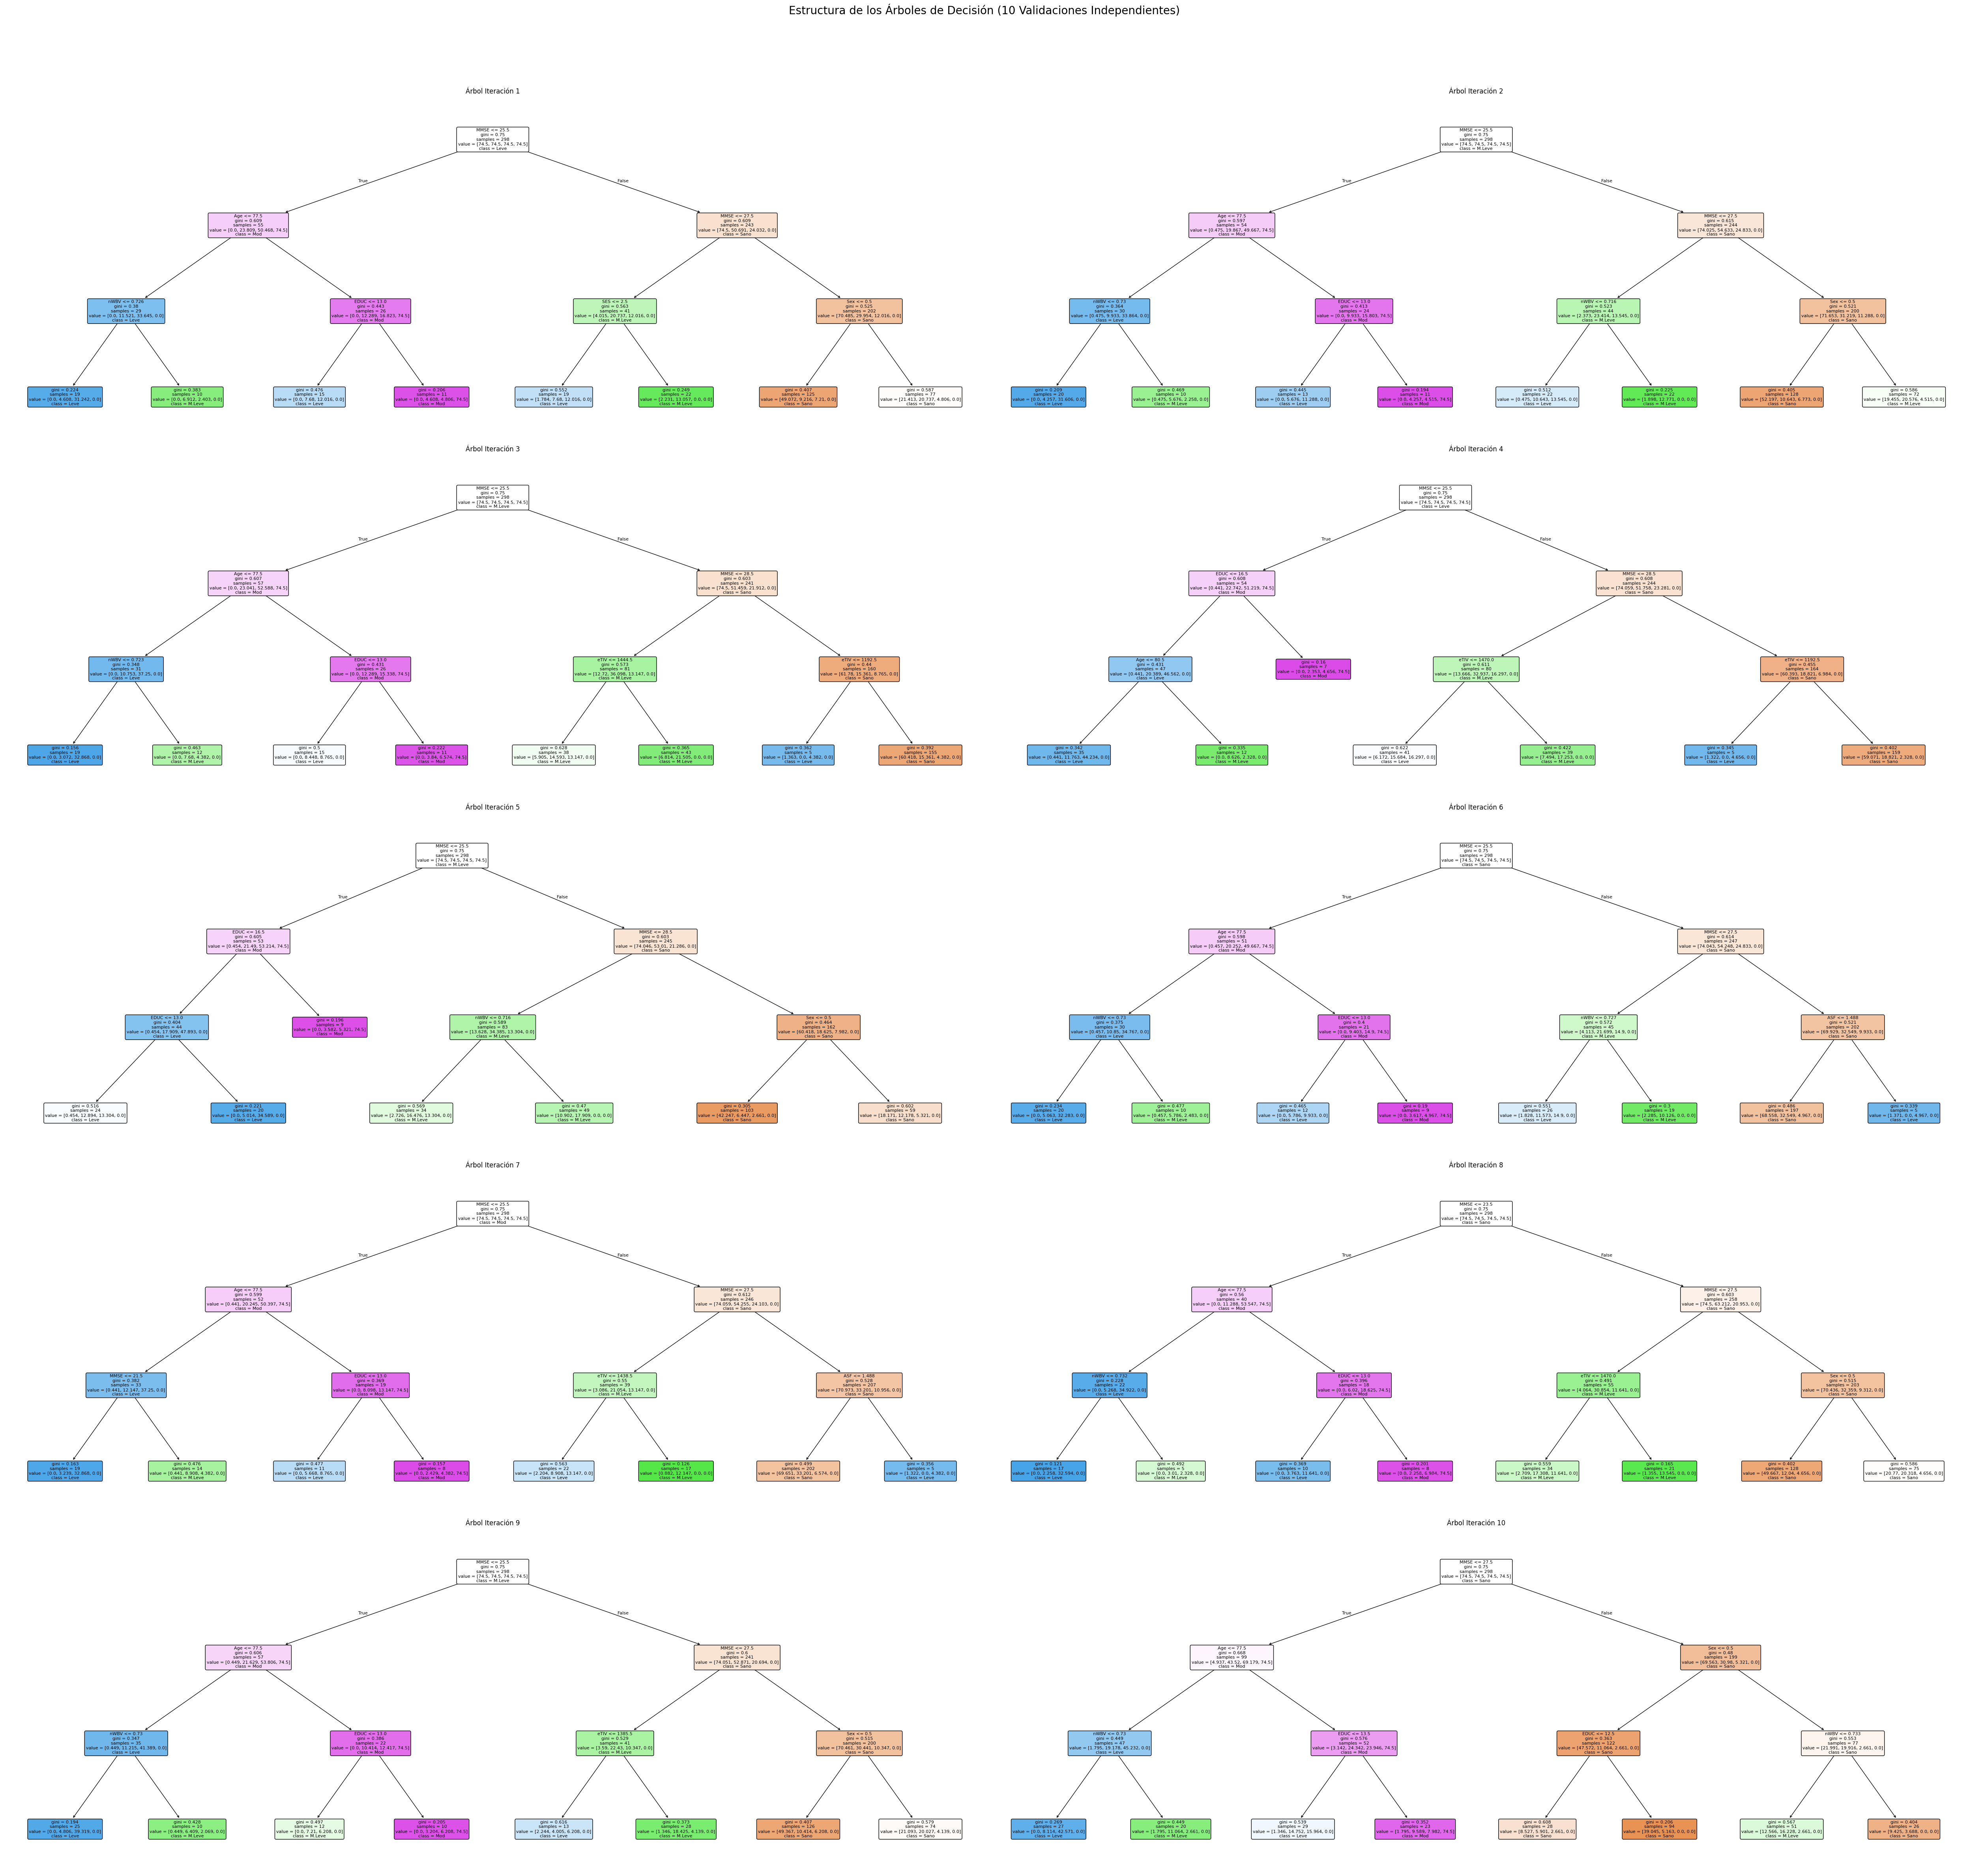

In [36]:
fig_tree, axes_tree = plt.subplots(5, 2, figsize=(50, 50))
axes_tree = axes_tree.flatten()

print("Generando visualización de la estructura de los 10 árboles...")

for i in range(10):
    # Visualizamos cada árbol entrenado en su respectivo subplot
    plot_tree(modelos_iter[i], 
              feature_names=features, 
              class_names=['Sano', 'M.Leve', 'Leve', 'Mod'], 
              filled=True, 
              rounded=True, 
              ax=axes_tree[i],
              fontsize=8)
    axes_tree[i].set_title(f"Árbol Iteración {i+1}")

fig_tree.suptitle("Estructura de los Árboles de Decisión (10 Validaciones Independientes)", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()